In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Presentation of the data:

**The Primary Anchor (1 asset)**: 

- rough rice futures (source: Investing.com)

**The Sector Proxies (2–4 assets): Relevant ETFs to capture broader sector beta**
- Invesco DB Agriculture Fund, DBA (yfinance)
- iPath Bloomberg Grains ETN, JJG (yfinance)
- Elements Rogers International Agriculture ETN, RJA (yfinance)
- WisdomTree Grains ETF, 1688.T (yfinance)

**The Individual Universe (10–15 assets): companies
directly involved in the commodity’s value chain**


- KRBL Limited, KRBL.NS (yfinance) – Indian company specializing in basmati rice production and export
- LT Foods Limited, LTFOODS.NS (yfinance) – Indian rice producer and owner of the Daawat basmati brand
- Chaman Lal Setia Exports Ltd, CLSEL.NS (yfinance) – Indian exporter of basmati rice
- Kohinoor Foods Ltd, KOHINOOR.NS (yfinance) – Indian basmati rice producer and exporter
- Archer Daniels Midland Company, ADM (yfinance) – Global agribusiness and grain trading company
- Bunge Global SA, BG (yfinance) – Multinational agribusiness and food company specializing in grain trading
- Olam Group Ltd, VC2.SI (yfinance) – Singapore-based agricultural commodity trader involved in rice and other crops
- Village Farms International Inc, VFF (yfinance) – Agricultural producer focused on controlled-environment farming
- Nutrien Ltd, NTR (yfinance) – Canadian agricultural input company and fertilizer producer supporting global crop production
- Mosaic Company, MOS (yfinance) – Major producer of phosphate and potash fertilizers used in agriculture
- CF Industries Holdings Inc, CF (yfinance) – Global manufacturer of nitrogen fertilizers for crop production
- Adecoagro SA, AGRO (yfinance) – Agricultural production company operating farms and food processing in South America
- Fresh Del Monte Produce Inc, FDP (yfinance) – Global agricultural company involved in food production and distribution


In [3]:
anchor  = pd.read_csv("futures_rice.csv")

sector_proxies = [
    "DBA",         
    "RJA",     
    "1688.T"   
]

companies = [
    "KRBL.NS",
    "LTFOODS.NS",
    "CLSEL.NS",
    "ADM",
    "BG",
    "VC2.SI",
    "VFF",
    "NTR",
    "MOS",
    "CF",
    "AGRO",
    "FDP"
]



In [4]:
tickers = sector_proxies + companies


data = yf.download(tickers, start="2018-01-01", progress=False)

close_prices = data["Close"]

print(close_prices.head())

Ticker      1688.T        ADM      AGRO         BG         CF  CLSEL.NS  \
Date                                                                      
2018-01-01   395.0        NaN       NaN        NaN        NaN       NaN   
2018-01-02   395.0  31.407619  9.198832  52.966419  35.073051       NaN   
2018-01-03   395.0  31.164757  9.394551  54.103817  35.081184       NaN   
2018-01-04   399.0  31.689655  9.350070  54.898434  35.447029       NaN   
2018-01-05   390.0  31.478134  9.207728  54.485550  35.503944       NaN   

Ticker            DBA        FDP     KRBL.NS  LTFOODS.NS        MOS  \
Date                                                                  
2018-01-01        NaN        NaN  556.974609         NaN        NaN   
2018-01-02  16.306482  39.298054  555.493835         NaN  23.238758   
2018-01-03  16.297886  39.524147  560.167603         NaN  23.029486   
2018-01-04  16.272099  40.353153  566.275940         NaN  23.386999   
2018-01-05  16.186142  40.361530  577.104492    

In [5]:
anchor["Date"] = pd.to_datetime(anchor["Date"], dayfirst=True)
anchor["Dernier"] = anchor["Dernier"].str.replace(",", ".").astype(float)
anchor = anchor.set_index("Date")

anchor_close = anchor["Dernier"].rename("Futures")

close_prices = close_prices.join(anchor_close)

In [6]:
close_prices

,1688.T,ADM,AGRO,BG,CF,CLSEL.NS,DBA,FDP,KRBL.NS,LTFOODS.NS,MOS,NTR,RJA,VC2.SI,VFF,Futures
Date,,,,,,,,,,,,,,,,
2018-01-01,395.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,556.974609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,395.000000,31.407619,9.198832,52.966419,35.073051,NaN,16.306482,39.298054,555.493835,NaN,23.238758,41.927891,6.06,1.330320,NaN,NaN
2018-01-03,395.000000,31.164757,9.394551,54.103817,35.081184,NaN,16.297886,39.524147,560.167603,NaN,23.029486,42.395031,6.08,1.310757,NaN,NaN
2018-01-04,399.000000,31.689655,9.350070,54.898434,35.447029,NaN,16.272099,40.353153,566.275940,NaN,23.386999,42.540524,6.08,1.330320,NaN,NaN
2018-01-05,390.000000,31.478134,9.207728,54.485550,35.503944,NaN,16.186142,40.361530,577.104492,NaN,23.421881,42.678371,6.04,1.330320,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09,NaN,67.919998,9.990000,118.790001,111.040001,243.449997,26.549999,41.919998,305.700012,379.799988,26.920000,75.809998,NaN,0.825000,3.38,NaN
2026-03-10,NaN,69.389999,10.210000,119.750000,110.050003,251.750000,26.610001,41.639999,313.350006,378.000000,26.480000,76.089996,NaN,0.830000,3.53,NaN
2026-03-11,NaN,70.830002,10.340000,122.720001,120.129997,248.850006,26.700001,41.169998,310.299988,382.750000,29.150000,79.309998,NaN,0.845000,3.51,NaN


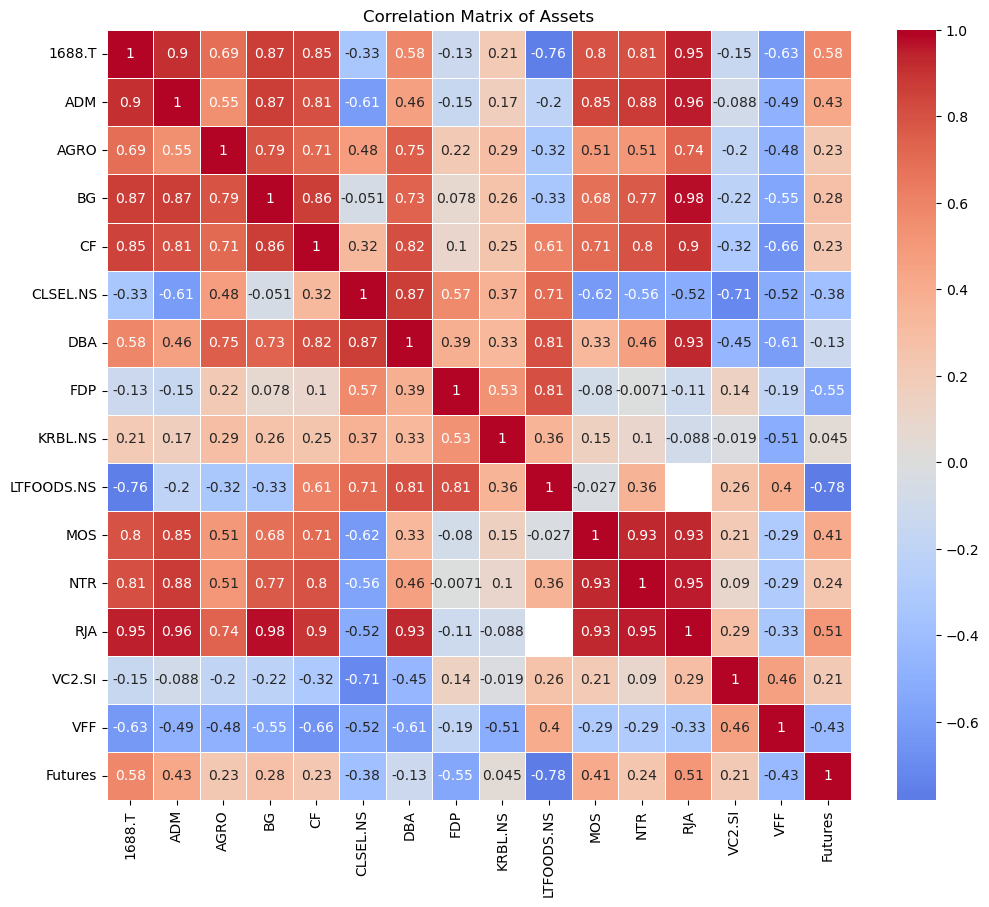

In [7]:
corr_matrix = close_prices.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Assets")
plt.show()

In [8]:
close_prices.to_csv("data.csv")